In [1]:
import json
import os
from metient import *
metient_input_dir = "/data/morrisq/divyak/projects/metient/data/quinn_lt_2021/metient_inputs/"
output_dir = "/data/morrisq/divyak/projects/metient/notebooks/lineage_tracing/outputs/"
organotropism_frequencies = "/data/morrisq/divyak/projects/metient/data/quinn_lt_2021/quinn2021_m5k_organotropism.json"

{'RW': 0.20334928229665072, 'RE': 0.20095693779904306, 'M2': 0.21291866028708134, 'M1': 0.21770334928229665, 'Liv': 0.16507177033492823}
/data/morrisq/divyak/projects/metient/data/quinn_lt_2021/metient_inputs/95.tsv
O: None
Tumor samples: ['M1', 'RE', 'M2', 'LL', 'RW']
input_T.shape torch.Size([49, 49])
Using sparse T: False


  0%|          | 0/700 [00:00<?, ?it/s]/lila/home/koyyald/mambaforge/envs/met/lib/python3.8/site-packages/torch/cuda/amp/grad_scaler.py:125: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(
 99%|█████████▉| 693/700 [00:17<00:00, 102.82it/s]

Fitch-hartigan result: (tensor([6.]), tensor([5.]), tensor([2.]), tensor([0.]), tensor([0.]))
Number of final solutions: 1
95_LL


<Figure size 640x480 with 0 Axes>

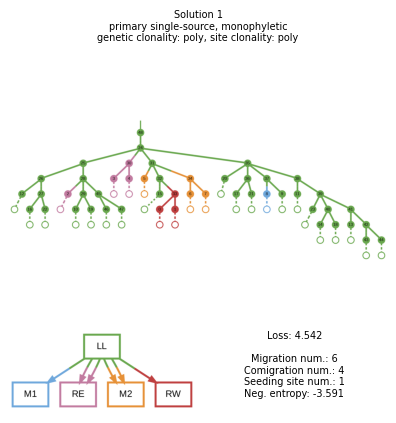

         1957501 function calls (1940817 primitive calls) in 21.114 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
    643/1    0.031    0.000   21.115   21.115 {built-in method builtins.exec}
        1    0.000    0.000   21.112   21.112 metient.py:33(evaluate_label_clone_tree)
        1    0.000    0.000   21.112   21.112 migration_history_inference.py:336(evaluate_label_clone_tree)
        1    0.000    0.000   21.112   21.112 migration_history_inference.py:345(evaluate)
        1    0.009    0.009   21.095   21.095 migration_history_inference.py:588(infer_migration_history)
        1    0.000    0.000   18.143   18.143 v_optimizer.py:63(run)
        1    0.003    0.003   18.143   18.143 v_optimizer.py:243(run_multiple_optimizations)
        7    0.067    0.010   16.692    2.385 v_optimizer.py:72(optimize_v_t)
        1    0.000    0.000   10.499   10.499 v_optimizer.py:165(first_v_optimization)
      700    0.235    

In [2]:
%%prun -s cumulative

with open(organotropism_frequencies, 'r') as json_file:
    O = json.load(json_file)
print(O)
clone = 95

colors = ["#6fa8dc","#c27ba0", "#e69138","#6aa84f","#bf4040","#9e9e9e"]

tree_fn = os.path.join(metient_input_dir, f"{clone}_tree.txt")
tsv_fn = os.path.join(metient_input_dir, f"{clone}.tsv")
print_config = PrintConfig(visualize=True, k_best_trees=6, display_labels=False, custom_colors=colors)
weights = Weights.pancancer_genetic_uniform_weighting()
evaluate_label_clone_tree(tree_fn, tsv_fn, weights, print_config, output_dir, clone,
                          solve_polytomies=False, sample_size=4096, num_runs=1)                          
